# Spam Email Detection

## 03. Feature Engineering and Feature Selection

### Feature Engineering

The `Message` text is converted into numerical features using TF-IDF.

### Feature Selection

Chi-Square (`chi2`) is used to identify informative text features.

### Leakage Prevention

The TF-IDF vectorizer and feature-selection process are fitted only on training data.

In [2]:
## output

from pathlib import Path

# Project root
BASE_DIR = Path.cwd().parent.parent

# Dataset
DATA_DIR = BASE_DIR / "data"

# Outputs
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

# Models
MODEL_DIR = BASE_DIR / "models"

# Create folders
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "email.csv"

print("PROJECT:", BASE_DIR)
print("DATASET:", DATA_PATH)
print("FIGURES:", FIGURE_DIR)
print("RESULTS:", RESULT_DIR)
print("MODELS:", MODEL_DIR)

PROJECT: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection
DATASET: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\data\email.csv
FIGURES: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\outputs\figures
RESULTS: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\outputs\results
MODELS: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\models


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

BASE_DIR = Path.cwd().parent.parent

DATA_PATH = BASE_DIR / "data" / "email.csv"

OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

df["Category"] = df["Category"].astype(str).str.strip().str.lower()

df = df[
    df["Category"].isin(["ham", "spam"])
].copy()

df["Message"] = df["Message"].astype(str)

df = df.drop_duplicates().reset_index(drop=True)

df["label"] = df["Category"].map({
    "ham": 0,
    "spam": 1
})

print(df.shape)

(5157, 3)


In [4]:
X = df["Message"]
y = df["label"]

print("X = Message")
print("Y = Category / label")

print("X shape:", X.shape)
print("Y shape:", y.shape)

X = Message
Y = Category / label
X shape: (5157,)
Y shape: (5157,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4125
Testing samples: 1032


In [6]:
split_result = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Rows": [len(X_train), len(X_test)]
})

split_result.to_csv(
    RESULT_DIR / "10_train_test_split.csv",
    index=False
)

split_result

,Dataset,Rows
0,Training,4125
1,Testing,1032


In [7]:
# ============================================================
# TF-IDF FEATURE EXTRACTION
# ============================================================

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (4125, 5619)
TF-IDF testing shape: (1032, 5619)


In [8]:
# ============================================================
# CHI-SQUARE FEATURE SELECTION
# ============================================================

feature_names = np.array(
    tfidf.get_feature_names_out()
)

k = min(3000, X_train_tfidf.shape[1])

selector = SelectKBest(
    score_func=chi2,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train_tfidf,
    y_train
)

X_test_selected = selector.transform(
    X_test_tfidf
)

selected_features = feature_names[
    selector.get_support()
]

print("Original TF-IDF features:", X_train_tfidf.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original TF-IDF features: 5619
Selected features: 3000


In [9]:
selected_feature_df = pd.DataFrame({
    "Feature": selected_features
})

selected_feature_df.to_csv(
    RESULT_DIR / "11_selected_features.csv",
    index=False
)

selected_feature_df.head(30)

,Feature
0,00
1,00 sub
2,000
3,000 bonus
4,000 cash
5,000 prize
6,000 xmas
7,02
8,02 06
9,02 09


In [10]:
chi_scores = selector.scores_

selected_mask = selector.get_support()

selected_scores = chi_scores[selected_mask]

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Chi2_Score": selected_scores
})

feature_importance = feature_importance.sort_values(
    "Chi2_Score",
    ascending=False
)

feature_importance.to_csv(
    RESULT_DIR / "12_chi_square_feature_importance.csv",
    index=False
)

feature_importance.head(20)

,Feature,Chi2_Score
2653,txt,85.645312
702,claim,84.184563
1699,mobile,77.846281
2948,www,71.279829
2072,prize,69.202925
1106,free,66.425427
2686,uk,64.587713
142,150p,57.101910
2296,service,55.384562
2742,urgent,50.438149


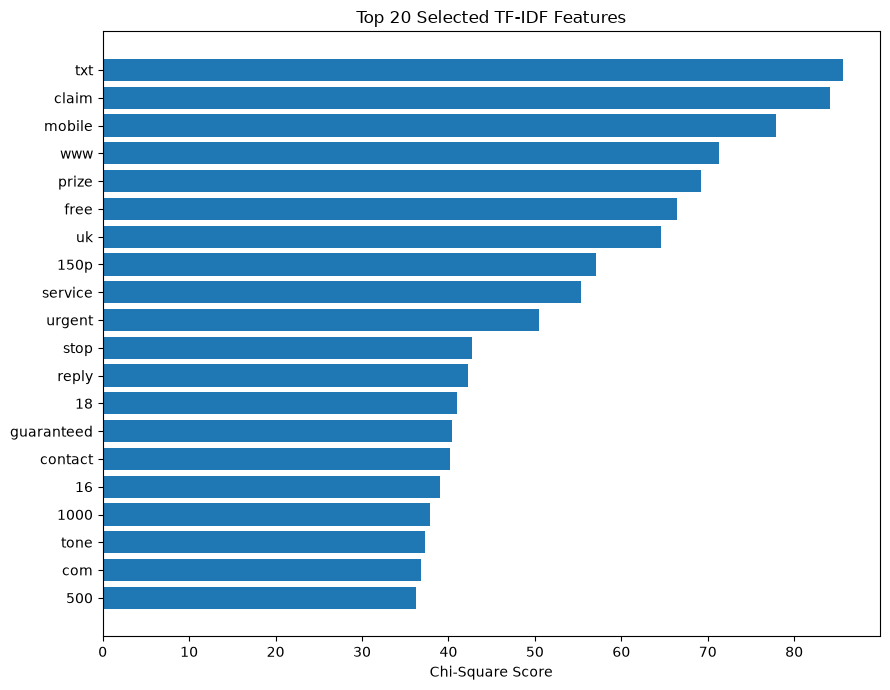

In [11]:
top_features = feature_importance.head(20).sort_values(
    "Chi2_Score"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"],
    top_features["Chi2_Score"]
)

plt.title("Top 20 Selected TF-IDF Features")
plt.xlabel("Chi-Square Score")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "06_top_chi_square_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()